In [ ]:
from sklearn.preprocessing import StandardScaler
from utils import *
from linear_regression import *

## Load data

In [2]:
data_path = '../data/processed/'
X_train = load_data(f'{data_path}/X_train.csv').values
X_val = load_data(f'{data_path}/X_val.csv').values
X_test = load_data(f'{data_path}/X_test.csv').values
y_train = load_data(f'{data_path}/y_train.csv').values
y_val = load_data(f'{data_path}/y_val.csv').values
y_test = load_data(f'{data_path}/y_test.csv').values

## Train Linear Regression with sklearn

In [3]:
lr_sklearn = LinearRegressionSklearn()
lr_sklearn.fit(X_train, y_train)

In [4]:
test_model(lr_sklearn, X_val, y_val)
test_model(lr_sklearn, X_test, y_test)

Mean Squared Error (MSE): 376.1353
R^2 Score: 0.4875
Mean Squared Error (MSE): 351.8113
R^2 Score: 0.5457


## Normalize data for later training 

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Train Linear Regression using Numpy

In [6]:
lr_numpy = LinearRegressionNumpy(n_features=X_train.shape[1], lr=0.01)
train_losses, val_losses = lr_numpy.fit(X_train, y_train, X_val, y_val, epochs=1000)

Epoch [100/1000], Train Loss: 4734.3656, Val Loss: 4817.8621
Epoch [200/1000], Train Loss: 970.3828, Val Loss: 985.2464
Epoch [300/1000], Train Loss: 464.0453, Val Loss: 463.6798
Epoch [400/1000], Train Loss: 394.5433, Val Loss: 390.8531
Epoch [500/1000], Train Loss: 383.9295, Val Loss: 380.0882
Epoch [600/1000], Train Loss: 381.4331, Val Loss: 378.2630
Epoch [700/1000], Train Loss: 380.1853, Val Loss: 377.8174
Epoch [800/1000], Train Loss: 379.2294, Val Loss: 377.6035
Epoch [900/1000], Train Loss: 378.4137, Val Loss: 377.4323
Epoch [1000/1000], Train Loss: 377.7011, Val Loss: 377.2731


In [7]:
test_model(lr_numpy, X_test, y_test)

Mean Squared Error (MSE): 347.4429
R^2 Score: 0.5514


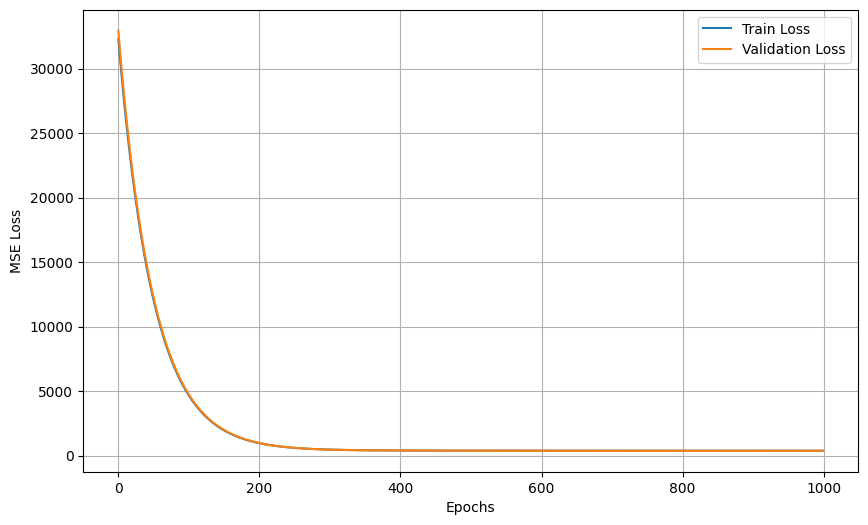

In [8]:
plot_loss(train_losses, val_losses)

## Train Linear Regression using Torch

In [9]:
lr_torch = LinearRegressionTorch(X_train.shape[1], lr=0.01)
train_losses, val_losses = lr_torch.fit(X_train, y_train, X_val, y_val, epochs=1000)

Epoch [100/1000], Train Loss: 971.7960, Val Loss: 989.4641
Epoch [200/1000], Train Loss: 395.0164, Val Loss: 391.5775
Epoch [300/1000], Train Loss: 382.0911, Val Loss: 379.3741
Epoch [400/1000], Train Loss: 379.8968, Val Loss: 378.7977
Epoch [500/1000], Train Loss: 378.3553, Val Loss: 378.4426
Epoch [600/1000], Train Loss: 377.1472, Val Loss: 378.0892
Epoch [700/1000], Train Loss: 376.1831, Val Loss: 377.7747
Epoch [800/1000], Train Loss: 375.4045, Val Loss: 377.5130
Epoch [900/1000], Train Loss: 374.7698, Val Loss: 377.3025
Epoch [1000/1000], Train Loss: 374.2482, Val Loss: 377.1366


/Users/toanly/Main/Class/Deep Learning/CS-5137-Deep-Learning/homework1/src/linear_regression.py:141: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32)


In [10]:
test_model(lr_torch, X_test, y_test)

Mean Squared Error (MSE): 348.6522
R^2 Score: 0.5498


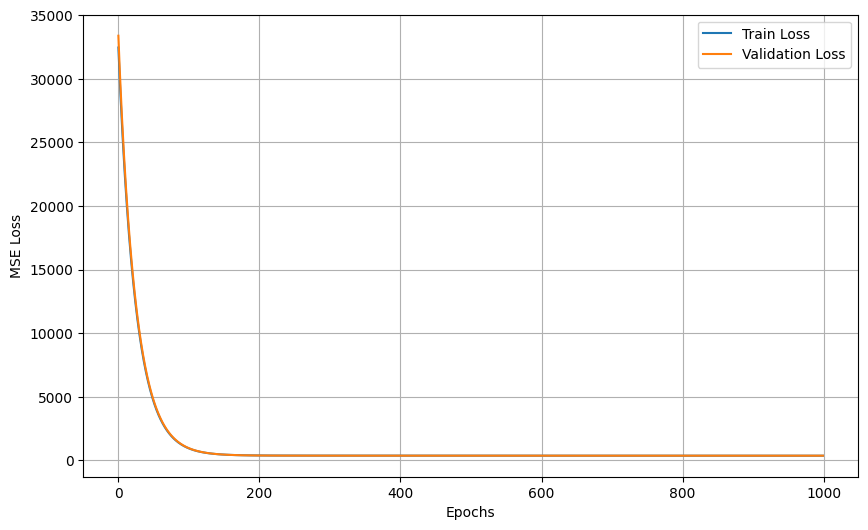

In [11]:
plot_loss(train_losses, val_losses)